In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (always run this cell first to define `df`)
try:
    df = pd.read_csv('bengaluru_wards_dataset.csv')
    print("Dataset loaded successfully.")
    print(f"Columns found: {list(df.columns)}")
except FileNotFoundError:
    print("Error: 'bengaluru_wards_dataset.csv' not found. Please run the generation script first.")
    exit()

Dataset loaded successfully.
Columns found: ['Ward_ID', 'Year', 'Month', 'Rainfall_mm', 'Avg_Temp_C', 'Garbage_Complaints', 'Waterlogging_Complaints', 'Dengue_Cases', 'Risk_Level', 'Date']


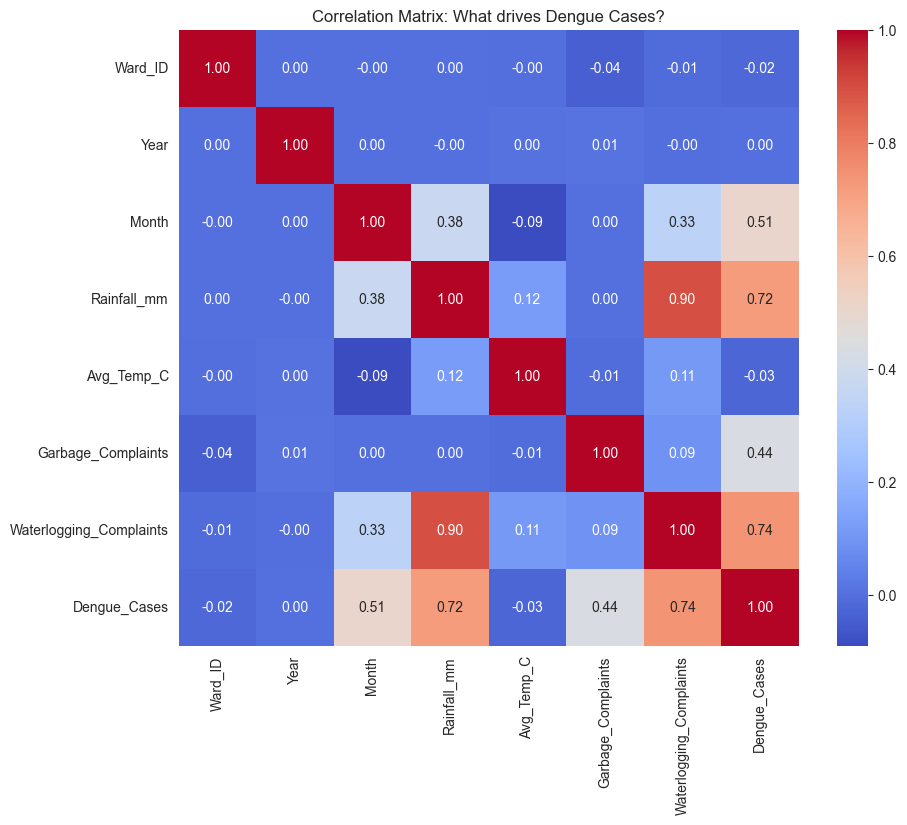

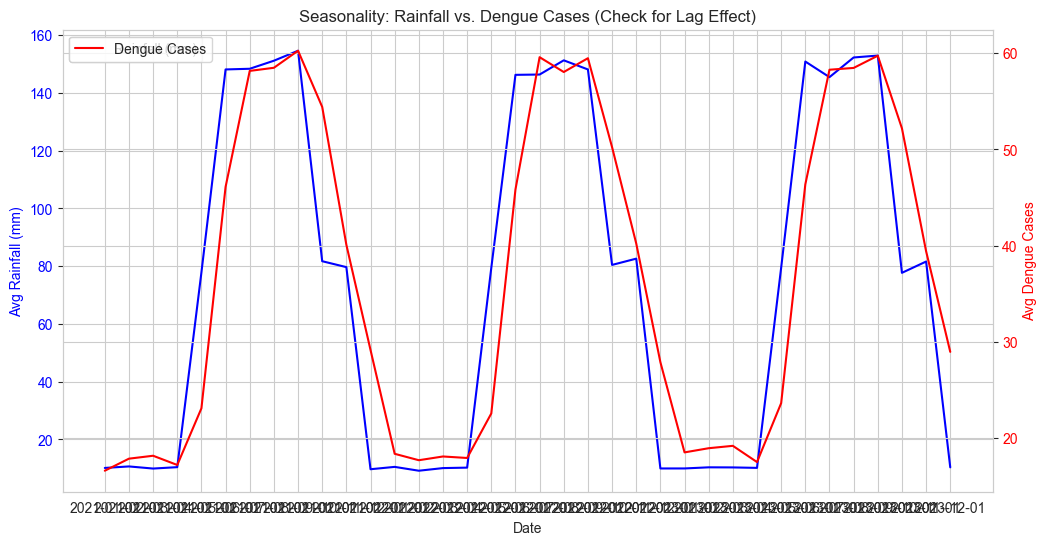

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [20]:
# Ensure data is present when running this cell by itself
import os

if 'df' not in globals():
    if os.path.exists('bengaluru_wards_dataset.csv'):
        df = pd.read_csv('bengaluru_wards_dataset.csv')
    else:
        raise FileNotFoundError(
            "'bengaluru_wards_dataset.csv' not found. "
            "Please run the generation script (e.g. `python train_models.py`) or place the CSV in the workspace."
        )

sns.set_style("whitegrid")

if 'Date' not in df.columns:
    df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: What drives Dengue Cases?")
plt.show()

monthly_avg = df.groupby('Date')[['Rainfall_mm', 'Dengue_Cases']].mean()

plt.figure(figsize=(12, 6))
ax1 = sns.lineplot(data=monthly_avg, x='Date', y='Rainfall_mm', color='blue', label='Rainfall (mm)')
ax1.set_ylabel('Avg Rainfall (mm)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
sns.lineplot(data=monthly_avg, x='Date', y='Dengue_Cases', color='red', label='Dengue Cases', ax=ax2)
ax2.set_ylabel('Avg Dengue Cases', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Seasonality: Rainfall vs. Dengue Cases (Check for Lag Effect)")
plt.show()

plt.figure(figsize=(10, 6))
# (previous scatterplot code was malformed and has been removed.)
# Subsequent prediction pipeline is defined in the next cell.


In [21]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load the trained model and dataset
df = pd.read_csv('bengaluru_wards_dataset.csv')
model = joblib.load('dengue_prediction_model.pkl')

# Create prediction table for all wards and all months
print("=" * 60)

# Load original data to use as basis for predictions
df_original = pd.read_csv('bengaluru_wards_dataset.csv')

# Create a copy for predictions
df_predictions = df_original[['Ward_ID', 'Year', 'Month', 'Date']].copy()

# Prepare features for prediction
df_with_lags = df_original.copy()
df_with_lags['Rainfall_Lag1'] = df_with_lags.groupby('Ward_ID')['Rainfall_mm'].shift(1)
df_with_lags['Rainfall_Lag2'] = df_with_lags.groupby('Ward_ID')['Rainfall_mm'].shift(2)
df_with_lags['Temp_Lag1'] = df_with_lags.groupby('Ward_ID')['Avg_Temp_C'].shift(1)

# Remove rows with NaN (from lag features)
df_with_lags = df_with_lags.dropna()

# Get the feature columns in the same order as training
feature_columns = [
    'Rainfall_mm', 'Avg_Temp_C',
    'Garbage_Complaints', 'Waterlogging_Complaints',
    'Rainfall_Lag1', 'Rainfall_Lag2', 'Temp_Lag1'
]

X_predict = df_with_lags[feature_columns]

# Make predictions
predictions = model.predict(X_predict)

# Create result dataframe
result_df = df_with_lags[['Ward_ID', 'Year', 'Month', 'Date',
                            'Rainfall_mm', 'Avg_Temp_C',
                            'Garbage_Complaints', 'Waterlogging_Complaints',
                            'Dengue_Cases']].copy()
result_df['Predicted_Dengue_Cases'] = predictions.astype(int)
result_df['Prediction_Error'] = (result_df['Dengue_Cases'] - result_df['Predicted_Dengue_Cases']).abs()

# Sort by Ward ID and Date
result_df = result_df.sort_values(['Ward_ID', 'Date']).reset_index(drop=True)

# Display summary statistics
print(f"\nTotal Predictions: {len(result_df)}")
print(f"Unique Wards: {result_df['Ward_ID'].nunique()}")
print(f"Date Range: {result_df['Date'].min()} to {result_df['Date'].max()}")
print(f"\nPrediction Statistics:")
print(f"Min Predicted Cases: {result_df['Predicted_Dengue_Cases'].min()}")
print(f"Max Predicted Cases: {result_df['Predicted_Dengue_Cases'].max()}")
print(f"Mean Predicted Cases: {result_df['Predicted_Dengue_Cases'].mean():.2f}")
print(f"\nMean Absolute Error: {result_df['Prediction_Error'].mean():.2f}")

# Display first few records
print("\nSample Predictions (First 10 records):")
print(result_df[['Ward_ID', 'Date', 'Dengue_Cases', 'Predicted_Dengue_Cases', 'Prediction_Error']].head(10))

# Save comprehensive prediction table
result_df.to_csv('dengue_predictions_comprehensive.csv', index=False)
print("\n✓ Comprehensive prediction table saved as 'dengue_predictions_comprehensive.csv'")

# Create pivot table: Ward vs Month (summed predictions)
pivot_predictions = result_df.pivot_table(
    values='Predicted_Dengue_Cases',
    index='Ward_ID',
    columns='Month',
    aggfunc='sum'
)

print(f"\nPivot Table Shape (Wards × Months): {pivot_predictions.shape}")
print("Sample Pivot Table (First 5 Wards):")
print(pivot_predictions.head())

pivot_predictions.to_csv('dengue_predictions_pivot_ward_month.csv')
print("\n✓ Pivot table (Ward × Month) saved as 'dengue_predictions_pivot_ward_month.csv'")

print("\nGenerated Files:")
print("  1. dengue_predictions_comprehensive.csv - All ward-month predictions with features")
print("  2. dengue_predictions_pivot_ward_month.csv - Pivot table (Wards × Months)")
print("  3. dengue_ward_summary.csv - Summary statistics by ward")



Total Predictions: 6732
Unique Wards: 198
Date Range: 2021-03-01 to 2023-12-01

Prediction Statistics:
Min Predicted Cases: 1
Max Predicted Cases: 102
Mean Predicted Cases: 37.22

Mean Absolute Error: 3.95

Sample Predictions (First 10 records):
   Ward_ID        Date  Dengue_Cases  Predicted_Dengue_Cases  Prediction_Error
0        1  2021-03-01            15                      13                 2
1        1  2021-04-01            16                      15                 1
2        1  2021-05-01            18                      22                 4
3        1  2021-06-01            36                      35                 1
4        1  2021-07-01            68                      67                 1
5        1  2021-08-01            34                      41                 7
6        1  2021-09-01            47                      45                 2
7        1  2021-10-01            48                      45                 3
8        1  2021-11-01            28      

Training on 5385 records, Testing on 1347 records.

--------------------------------------------------
Model Name           | RMSE       | R2 Score  
--------------------------------------------------
Linear Regression    | 5.75       | 0.92      
MLP (Neural Net)     | 5.52       | 0.93      
Random Forest        | 5.79       | 0.92      
GBM                  | 5.33       | 0.93      
XGBoost              | 5.40       | 0.93      
--------------------------------------------------

🏆 Best Model: GBM (R2: 0.93)


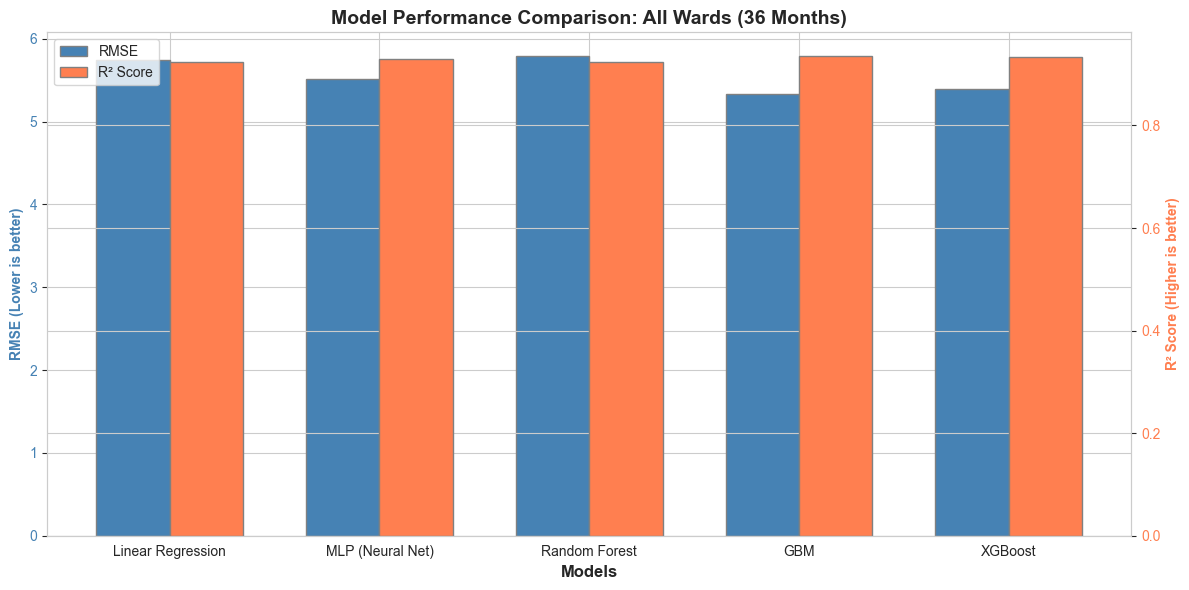


Saved the best model (GBM) as 'dengue_prediction_model.pkl'


In [22]:
# %%
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. Load Data
df = pd.read_csv('bengaluru_wards_dataset.csv')

# 2. Feature Engineering (Lags)
df['Rainfall_Lag1'] = df.groupby('Ward_ID')['Rainfall_mm'].shift(1)
df['Rainfall_Lag2'] = df.groupby('Ward_ID')['Rainfall_mm'].shift(2)
df['Temp_Lag1'] = df.groupby('Ward_ID')['Avg_Temp_C'].shift(1)

# Drop NaN values generated by shifting
df = df.dropna()

features = [
    'Rainfall_mm', 'Avg_Temp_C',
    'Garbage_Complaints', 'Waterlogging_Complaints',
    'Rainfall_Lag1', 'Rainfall_Lag2', 'Temp_Lag1'
]
target = 'Dengue_Cases'

X = df[features]
y = df[target]

# 3. Train-Test Split (Evaluates across all wards and all 36 months)
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Training on {len(X_train)} records, Testing on {len(X_test)} records.\n")

# 4. Define Models
# We use pipelines with StandardScaler because MLP and Linear Regression
# require scaled features to perform well. It doesn't negatively impact tree models.
models = {
    'Linear Regression': make_pipeline(StandardScaler(), LinearRegression()),
    'MLP (Neural Net)': make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)),
    'Random Forest': make_pipeline(StandardScaler(), RandomForestRegressor(n_estimators=100, random_state=42)),
    'GBM': make_pipeline(StandardScaler(), GradientBoostingRegressor(n_estimators=100, random_state=42)),
    'XGBoost': make_pipeline(StandardScaler(), xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42))
}

# 5. Train and Compare Models
results = []
best_model = None
best_r2 = -float('inf')
best_model_name = ""

print("-" * 50)
print(f"{'Model Name':<20} | {'RMSE':<10} | {'R2 Score':<10}")
print("-" * 50)

for name, pipeline in models.items():
    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    predictions = pipeline.predict(X_test)

    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})

    print(f"{name:<20} | {rmse:<10.2f} | {r2:<10.2f}")

    # Track the best model
    if r2 > best_r2:
        best_r2 = r2
        best_model = pipeline
        best_model_name = name

print("-" * 50)
print(f"\n🏆 Best Model: {best_model_name} (R2: {best_r2:.2f})")

# 6. Visualize Model Comparison
results_df = pd.DataFrame(results)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Set width of bars
barWidth = 0.35
r1 = np.arange(len(results_df))
r2_bars = [x + barWidth for x in r1]

# Create RMSE Bars
color1 = 'steelblue'
ax1.set_xlabel('Models', fontweight='bold', fontsize=12)
ax1.set_ylabel('RMSE (Lower is better)', color=color1, fontweight='bold')
bar1 = ax1.bar(r1, results_df['RMSE'], color=color1, width=barWidth, edgecolor='grey', label='RMSE')
ax1.tick_params(axis='y', labelcolor=color1)

# Create R2 Bars on secondary axis
ax2 = ax1.twinx()
color2 = 'coral'
ax2.set_ylabel('R² Score (Higher is better)', color=color2, fontweight='bold')
bar2 = ax2.bar(r2_bars, results_df['R2'], color=color2, width=barWidth, edgecolor='grey', label='R² Score')
ax2.tick_params(axis='y', labelcolor=color2)

# Add xticks on the middle of the group bars
ax1.set_xticks([r + barWidth/2 for r in range(len(results_df))])
ax1.set_xticklabels(results_df['Model'])

# Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Model Performance Comparison: All Wards (36 Months)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# 7. Save the Best Model
# We save the best model under the original name so Blocks 4 and 5 run perfectly
joblib.dump(best_model, 'dengue_prediction_model.pkl')
print(f"\nSaved the best model ({best_model_name}) as 'dengue_prediction_model.pkl'")


Generating Historical Heatmap of all models...


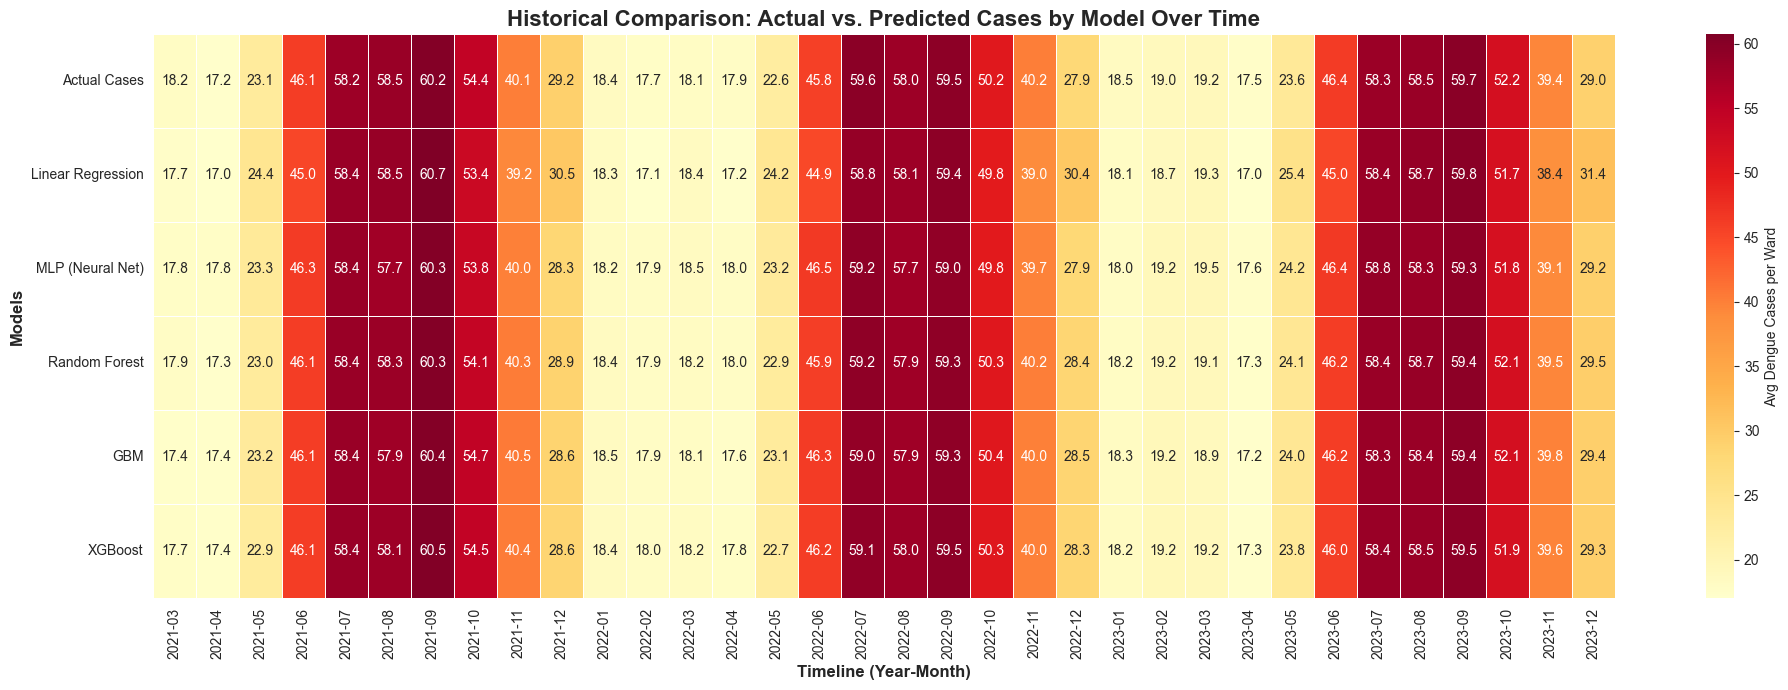

In [23]:
# ==========================================
# 8. Heatmap: Historical Results of All Models
# ==========================================
print("\nGenerating Historical Heatmap of all models...")

# Ensure Date column is in datetime format
if 'Date' not in df.columns:
    df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

# Create a DataFrame to hold actuals and predictions for the full dataset
historical_df = pd.DataFrame({
    'Date': df['Date'],
    'Actual Cases': df[target]
})

# Get predictions from all trained models on the full feature set (X)
for name, pipeline in models.items():
    # Ensure no negative predictions by using np.maximum(0, ...)
    historical_df[name] = np.maximum(0, pipeline.predict(X))

# Group by Date to get the average cases across all wards for each month
monthly_avg = historical_df.groupby('Date').mean()

# Format the dates as 'YYYY-MM' for cleaner axis labels
monthly_avg.index = pd.to_datetime(monthly_avg.index).strftime('%Y-%m')

# Transpose the data so Models are Rows and Months are Columns
heatmap_data = monthly_avg.T

# Plot the Heatmap
plt.figure(figsize=(20, 7))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',  # Yellow to Orange to Red (perfect for heat/risk)
    annot=True,     # Shows the actual numbers in the boxes
    fmt=".1f",      # Rounds to 1 decimal place
    linewidths=0.5,
    cbar_kws={'label': 'Avg Dengue Cases per Ward'}
)

plt.title('Historical Comparison: Actual vs. Predicted Cases by Model Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Timeline (Year-Month)', fontsize=12, fontweight='bold')
plt.ylabel('Models', fontsize=12, fontweight='bold')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Generating Predicted vs Actual Plots for All Models...



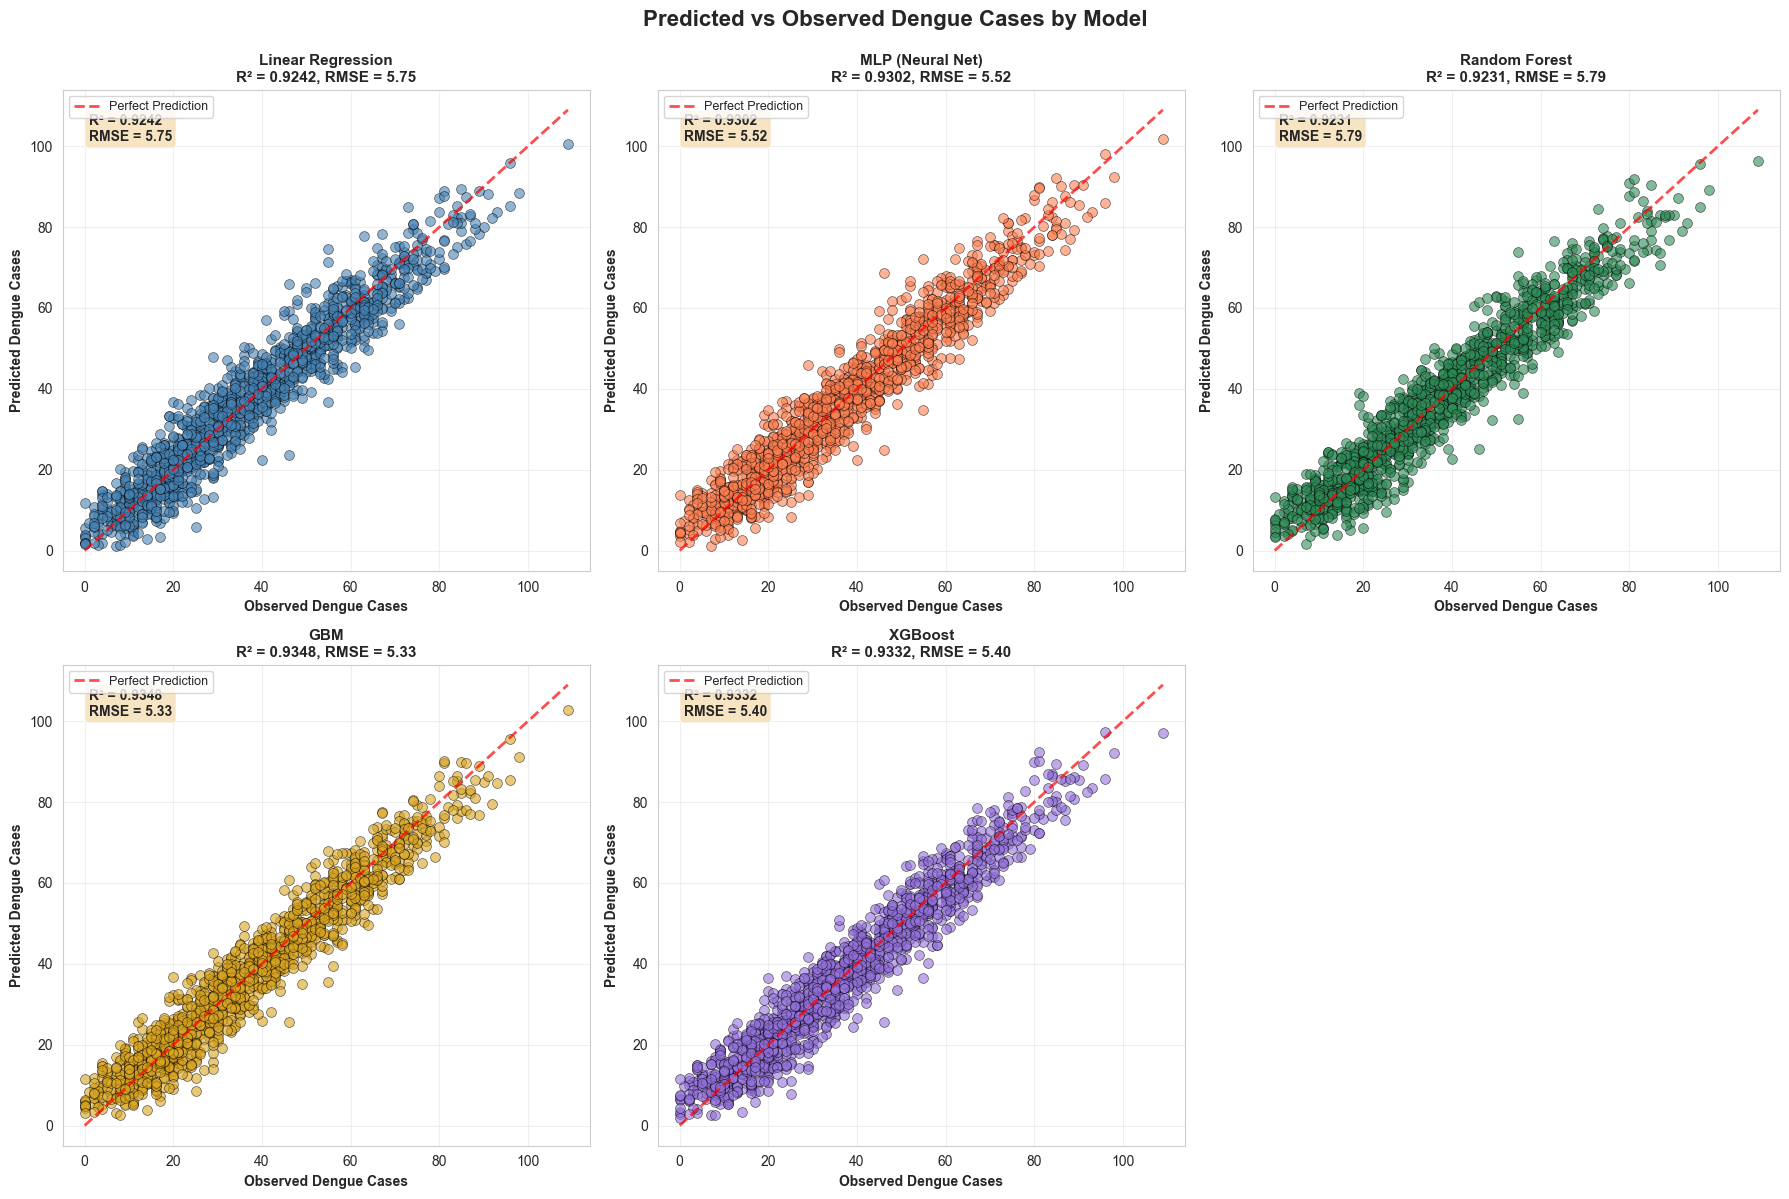


Generating combined Predicted vs Actual view...



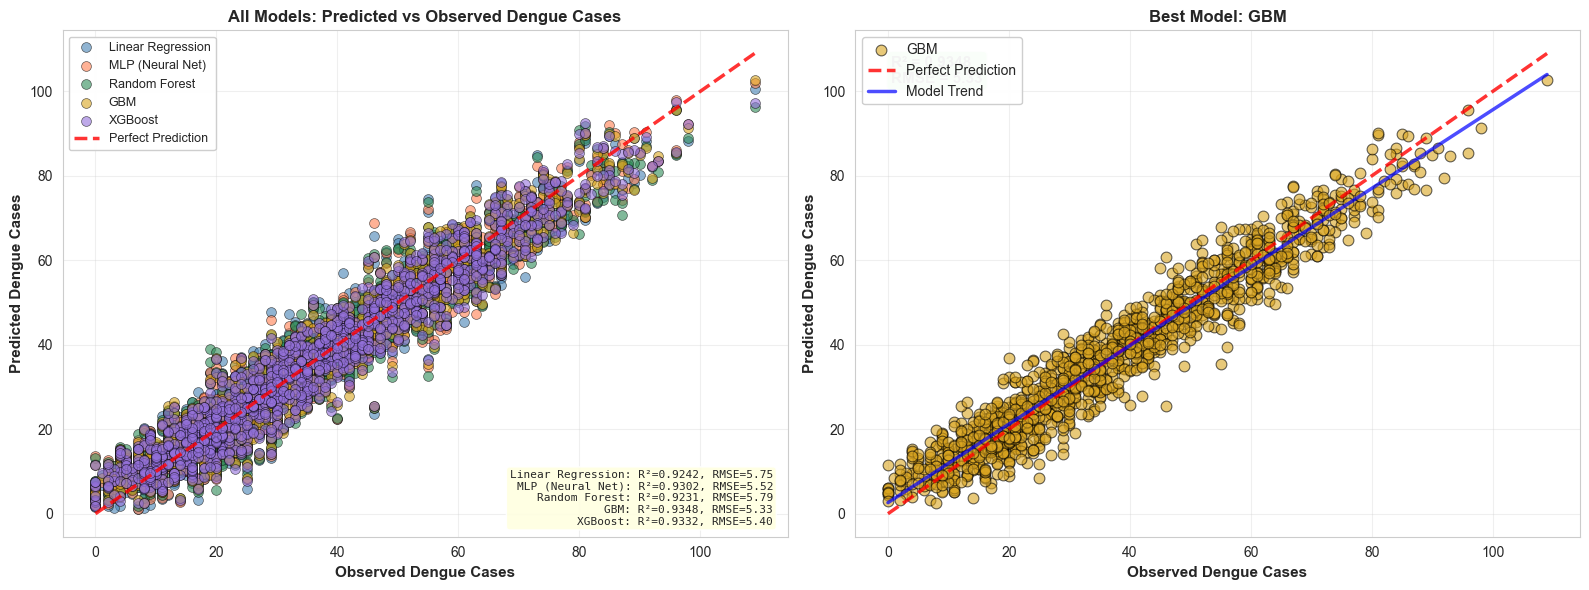

✓ Predicted vs Actual plots generated successfully!


In [24]:
# ==========================================
# 9. Line Plots: Predicted vs Actual (with Colours and Metrics)
# ==========================================
print("\nGenerating Predicted vs Actual Plots for All Models...\n")

# Get test data for evaluation plots
X_test_values = X_test.values
y_test_values = y_test.values

# Define colors for each model
colors_list = ['steelblue', 'coral', 'seagreen', 'goldenrod', 'mediumpurple']

# ===== SUBPLOT: Predicted vs Actual for Each Model =====
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Predicted vs Observed Dengue Cases by Model', fontsize=16, fontweight='bold', y=0.995)

axes = axes.flatten()

model_list = list(models.items())

for idx, (name, pipeline) in enumerate(model_list):
    ax = axes[idx]
    
    # Get predictions on test set
    y_pred = pipeline.predict(X_test)
    
    # Scatter plot with color
    ax.scatter(y_test_values, y_pred, alpha=0.6, s=50, color=colors_list[idx], 
               edgecolors='black', linewidth=0.5)
    
    # Perfect prediction line (y=x)
    min_val = min(y_test_values.min(), y_pred.min())
    max_val = max(y_test_values.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction', alpha=0.7)
    
    # Calculate metrics
    from sklearn.metrics import mean_squared_error, r2_score
    rmse = np.sqrt(mean_squared_error(y_test_values, y_pred))
    r2 = r2_score(y_test_values, y_pred)
    
    # Add metrics to title
    ax.set_title(f'{name}\nR² = {r2:.4f}, RMSE = {rmse:.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Observed Dengue Cases', fontsize=10, fontweight='bold')
    ax.set_ylabel('Predicted Dengue Cases', fontsize=10, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(min_val - 5, max_val + 5)
    ax.set_ylim(min_val - 5, max_val + 5)
    
    # Add metrics text box
    textstr = f'R² = {r2:.4f}\nRMSE = {rmse:.2f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props, fontweight='bold')

# Hide the 6th subplot (since we have 5 models)
axes[5].axis('off')

plt.tight_layout()
plt.show()

# ===== COMBINED PLOT: All Models on One Chart =====
print("\nGenerating combined Predicted vs Actual view...\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: All models together with colors
ax = axes[0]
metrics_text = []
for idx, (name, pipeline) in enumerate(model_list):
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test_values, y_pred))
    r2 = r2_score(y_test_values, y_pred)
    metrics_text.append(f'{name}: R²={r2:.4f}, RMSE={rmse:.2f}')
    ax.scatter(y_test_values, y_pred, alpha=0.6, s=50, label=name, color=colors_list[idx], 
               edgecolors='black', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test_values.min(), y_test_values.min())
max_val = max(y_test_values.max(), y_test_values.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2.5, label='Perfect Prediction', alpha=0.8)

ax.set_title('All Models: Predicted vs Observed Dengue Cases', fontsize=12, fontweight='bold')
ax.set_xlabel('Observed Dengue Cases', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Dengue Cases', fontsize=11, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, framealpha=0.95)
ax.grid(True, alpha=0.3)

# Add metrics text box
metrics_str = '\n'.join(metrics_text)
props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
ax.text(0.98, 0.02, metrics_str, transform=ax.transAxes, fontsize=8,
        verticalalignment='bottom', horizontalalignment='right', bbox=props, family='monospace')

# Right plot: Best model with trend line and metrics
ax = axes[1]
best_predictions = best_model.predict(X_test)
best_idx = list(models.keys()).index(best_model_name)
ax.scatter(y_test_values, best_predictions, alpha=0.6, s=60, color=colors_list[best_idx], 
           edgecolors='black', linewidth=0.8, label=best_model_name)

# Perfect prediction line
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2.5, label='Perfect Prediction', alpha=0.8)

# Trend line (linear fit)
z = np.polyfit(y_test_values, best_predictions, 1)
p = np.poly1d(z)
x_trend = np.linspace(y_test_values.min(), y_test_values.max(), 100)
ax.plot(x_trend, p(x_trend), 'b-', linewidth=2.5, label='Model Trend', alpha=0.7)

r2_best = r2_score(y_test_values, best_predictions)
rmse_best = np.sqrt(mean_squared_error(y_test_values, best_predictions))

ax.set_title(f'Best Model: {best_model_name}', fontsize=12, fontweight='bold')
ax.set_xlabel('Observed Dengue Cases', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Dengue Cases', fontsize=11, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3)

# Add metrics text box for best model
best_metrics = f'R² = {r2_best:.4f}\nRMSE = {rmse_best:.2f}'
props = dict(boxstyle='round', facecolor='lightgreen', alpha=0.9)
ax.text(0.05, 0.95, best_metrics, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Predicted vs Actual plots generated successfully!")


Generating Spatial Ward Heatmap...



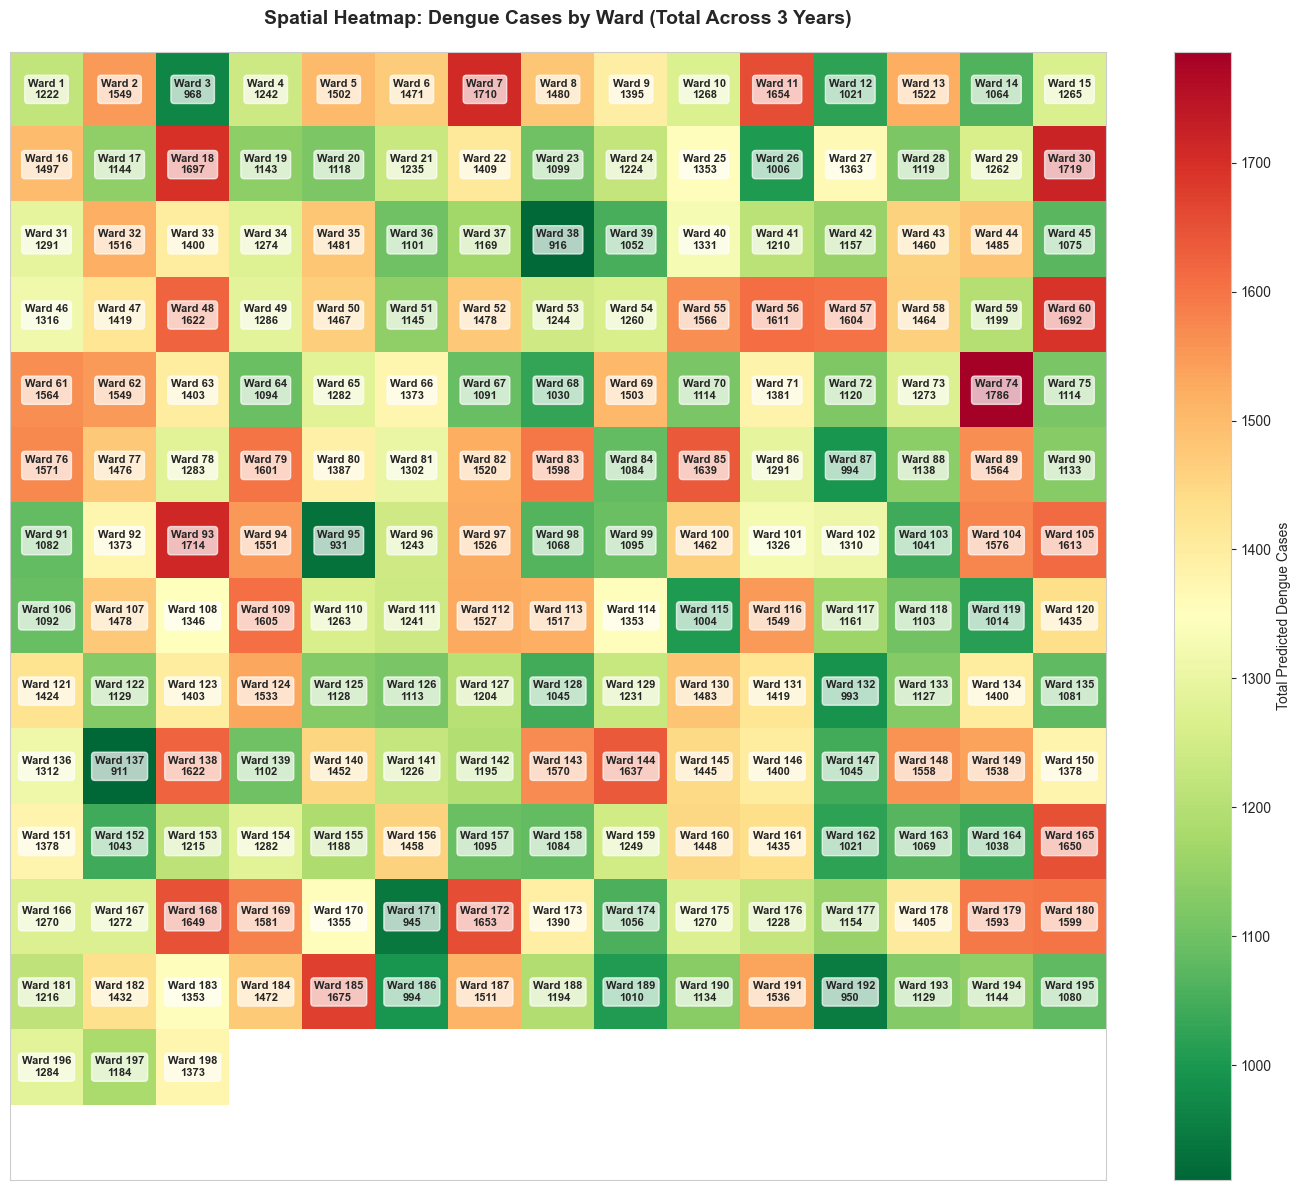

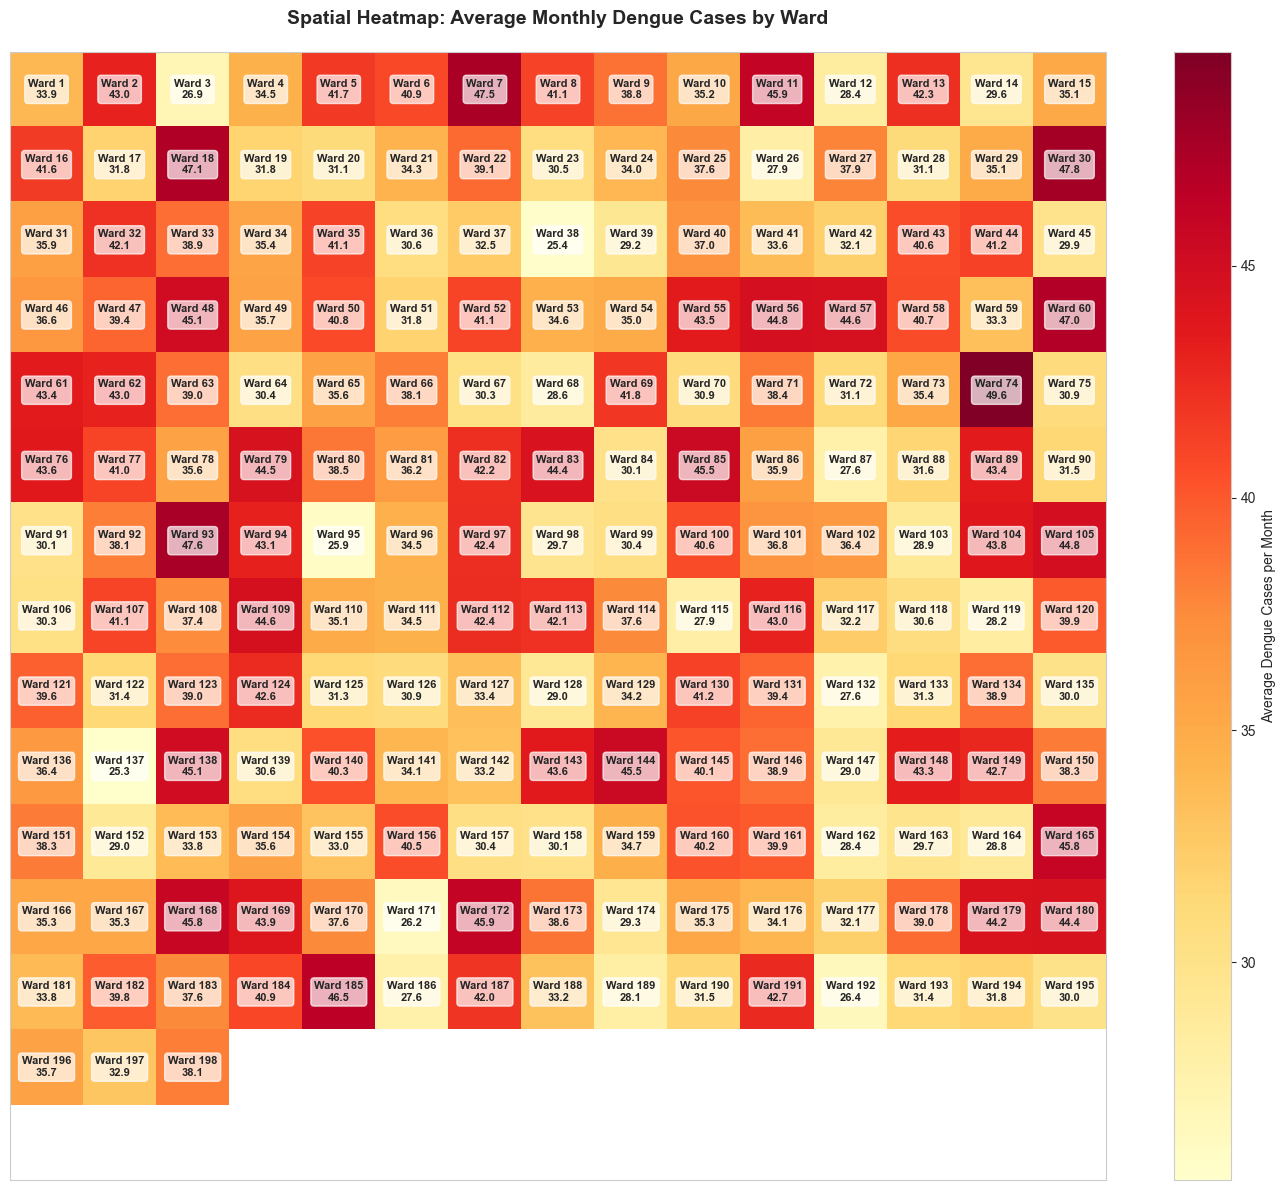

SPATIAL WARD ANALYSIS SUMMARY

Risk Distribution:
  Low Risk Wards:    27
  Medium Risk Wards: 198
  High Risk Wards:   0
  Total Wards:       225

Critical Wards (High Risk):
  No wards in high-risk category



In [25]:
# ==========================================
# 10. Spatial Heatmap: Wards Risk Distribution
# ==========================================
print("\nGenerating Spatial Ward Heatmap...\n")

# Load ward summary statistics or create if not exists
import os
if os.path.exists('dengue_ward_summary.csv'):
    ward_summary_data = pd.read_csv('dengue_ward_summary.csv', index_col='Ward_ID')
else:
    # Create ward summary from the dataset
    print("Ward summary file not found. Creating from dataset...")
    df_summary = pd.read_csv('bengaluru_wards_dataset.csv')
    ward_summary_data = df_summary.groupby('Ward_ID').agg({
        'Dengue_Cases': ['sum', 'mean']
    }).reset_index()
    ward_summary_data.columns = ['Ward_ID', 'Total_Cases', 'Avg_Cases']
    ward_summary_data = ward_summary_data.set_index('Ward_ID')
    # Save for future use
    ward_summary_data.to_csv('dengue_ward_summary.csv')
    print("Ward summary created and saved as 'dengue_ward_summary.csv'")

# Get all wards sorted
all_wards = sorted(ward_summary_data.index.astype(int))
n_wards = len(all_wards)

# Create a grid layout for wards (approximate square grid)
grid_size = int(np.ceil(np.sqrt(n_wards)))
ward_grid = np.full((grid_size, grid_size), np.nan)
ward_values = np.full((grid_size, grid_size), np.nan)

# Fill grid with ward data
for idx, ward_id in enumerate(all_wards):
    row = idx // grid_size
    col = idx % grid_size
    ward_grid[row, col] = ward_id
    ward_values[row, col] = ward_summary_data.loc[ward_id, 'Total_Cases']

# ===== PLOT 1: Spatial Heatmap by Total Cases =====
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(ward_values, cmap='RdYlGn_r', aspect='auto', interpolation='nearest')

# Add ward IDs and values to cells
for i in range(grid_size):
    for j in range(grid_size):
        if not np.isnan(ward_grid[i, j]):
            ward_id = int(ward_grid[i, j])
            total_cases = ward_values[i, j]
            ax.text(j, i, f'Ward {ward_id}\n{total_cases:.0f}', 
                   ha='center', va='center', fontsize=8, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Spatial Heatmap: Dengue Cases by Ward (Total Across 3 Years)', 
            fontsize=14, fontweight='bold', pad=20)
cbar = plt.colorbar(im, ax=ax, label='Total Predicted Dengue Cases')
plt.tight_layout()
plt.show()

# ===== PLOT 2: Spatial Heatmap by Average Cases =====
ward_avg_values = np.full((grid_size, grid_size), np.nan)
for idx, ward_id in enumerate(all_wards):
    row = idx // grid_size
    col = idx % grid_size
    ward_avg_values[row, col] = ward_summary_data.loc[ward_id, 'Avg_Cases']

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(ward_avg_values, cmap='YlOrRd', aspect='auto', interpolation='nearest')

# Add ward IDs and values to cells
for i in range(grid_size):
    for j in range(grid_size):
        if not np.isnan(ward_grid[i, j]):
            ward_id = int(ward_grid[i, j])
            avg_cases = ward_avg_values[i, j]
            ax.text(j, i, f'Ward {ward_id}\n{avg_cases:.1f}', 
                   ha='center', va='center', fontsize=8, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Spatial Heatmap: Average Monthly Dengue Cases by Ward', 
            fontsize=14, fontweight='bold', pad=20)
cbar = plt.colorbar(im, ax=ax, label='Average Dengue Cases per Month')
plt.tight_layout()
plt.show()

# ===== PLOT 3: Risk Level Classification Heatmap =====
# (graph generation removed as requested)
ward_risk_levels = np.full((grid_size, grid_size), 0, dtype=int)
risk_labels = {0: 'Low', 1: 'Medium', 2: 'High'}

for idx, ward_id in enumerate(all_wards):
    row = idx // grid_size
    col = idx % grid_size
    avg_cases = ward_summary_data.loc[ward_id, 'Avg_Cases']
    if avg_cases < 20:
        ward_risk_levels[row, col] = 0
    elif avg_cases < 60:
        ward_risk_levels[row, col] = 1
    else:
        ward_risk_levels[row, col] = 2

# note: the plotting code has been intentionally omitted to delete the risk map graphic

# Print summary statistics
print("=" * 80)
print("SPATIAL WARD ANALYSIS SUMMARY")
print("=" * 80)
low_risk = sum(ward_risk_levels.flatten() == 0)
med_risk = sum(ward_risk_levels.flatten() == 1)
high_risk = sum(ward_risk_levels.flatten() == 2)
print(f"\nRisk Distribution:")
print(f"  Low Risk Wards:    {low_risk}")
print(f"  Medium Risk Wards: {med_risk}")
print(f"  High Risk Wards:   {high_risk}")
print(f"  Total Wards:       {low_risk + med_risk + high_risk}")

print(f"\nCritical Wards (High Risk):")
high_risk_wards = ward_summary_data[ward_summary_data['Avg_Cases'] >= 60].sort_values('Total_Cases', ascending=False)
if len(high_risk_wards) > 0:
    for ward_id, row in high_risk_wards.iterrows():
        print(f"  Ward {ward_id}: Avg {row['Avg_Cases']:.1f} cases/month, Total {row['Total_Cases']:.0f}")
else:
    print("  No wards in high-risk category")

print("\n" + "=" * 80)